# Finalised K Tutorial
Here we demonstrate how to calculate the finalised K index

Provisional K is needed to calculate the finalised K index so we provide the raw data and the provisional K data.

finalised K can handle dataframes and file paths (csv, txt and hdf5). For the hdf5 case chunking is enabled to help with memory issues. four_day_multiple in final_kwargs adjusts the chunking bigger values improve speed but make it more memory heavy. This is not applicable to dataframes, csvs and txts


In [11]:
from magie import finalised_k
finalised_k('../Data/Dunsink.hdf5', '../Data/Dunsink.hdf5',
            final_kwargs={'four_day_multiple':2, 'kinkey':'provisional_K',
                            'inkey':'main',
                            'outfile': '../Data/Dunsink.hdf5',
                            'outkey':'final_K'})


Processing Finalised K blocks: 100%|██████████| 2/2 [00:01<00:00,  1.07it/s]


'../Data/Dunsink.hdf5'

# Provisional and Finalised in One
For simplicity if no provisional data is provide to finalised_k then provisional_k is calculated. This means that a single function call will perform all steps to get finalised K indices.
provisional_kwargs are passed to provisional_k.

Below is a quick step to delete the provisional and final K so that the capabilty to compute all in one function can be demonstrated

In [12]:
import pandas as pd

with pd.HDFStore('../Data/Dunsink.hdf5', mode='a') as store:
    store.remove('/provisional_K')
with pd.HDFStore('../Data/Dunsink.hdf5', mode='a') as store:
    store.remove('/final_K')


In [17]:
from magie import finalised_k
finalised_k('../Data/Dunsink.hdf5',
            provisional_kwargs={'outfile': '../Data/Dunsink.hdf5',
                                'outkey':'provisional_K', 'hr3_chunks':1,
                                'inkey':'main'},
            final_kwargs={'four_day_multiple':2, 'kinkey':'provisional_K',
                            'inkey':'main',
                            'outfile': '../Data/Dunsink.hdf5',
                            'outkey':'final_K'}, use_mag_filter=False)

Processing Finalised K blocks: 100%|██████████| 2/2 [00:01<00:00,  1.18it/s]


'../Data/Dunsink.hdf5'

Text(0.5, 0.98, 'Final')

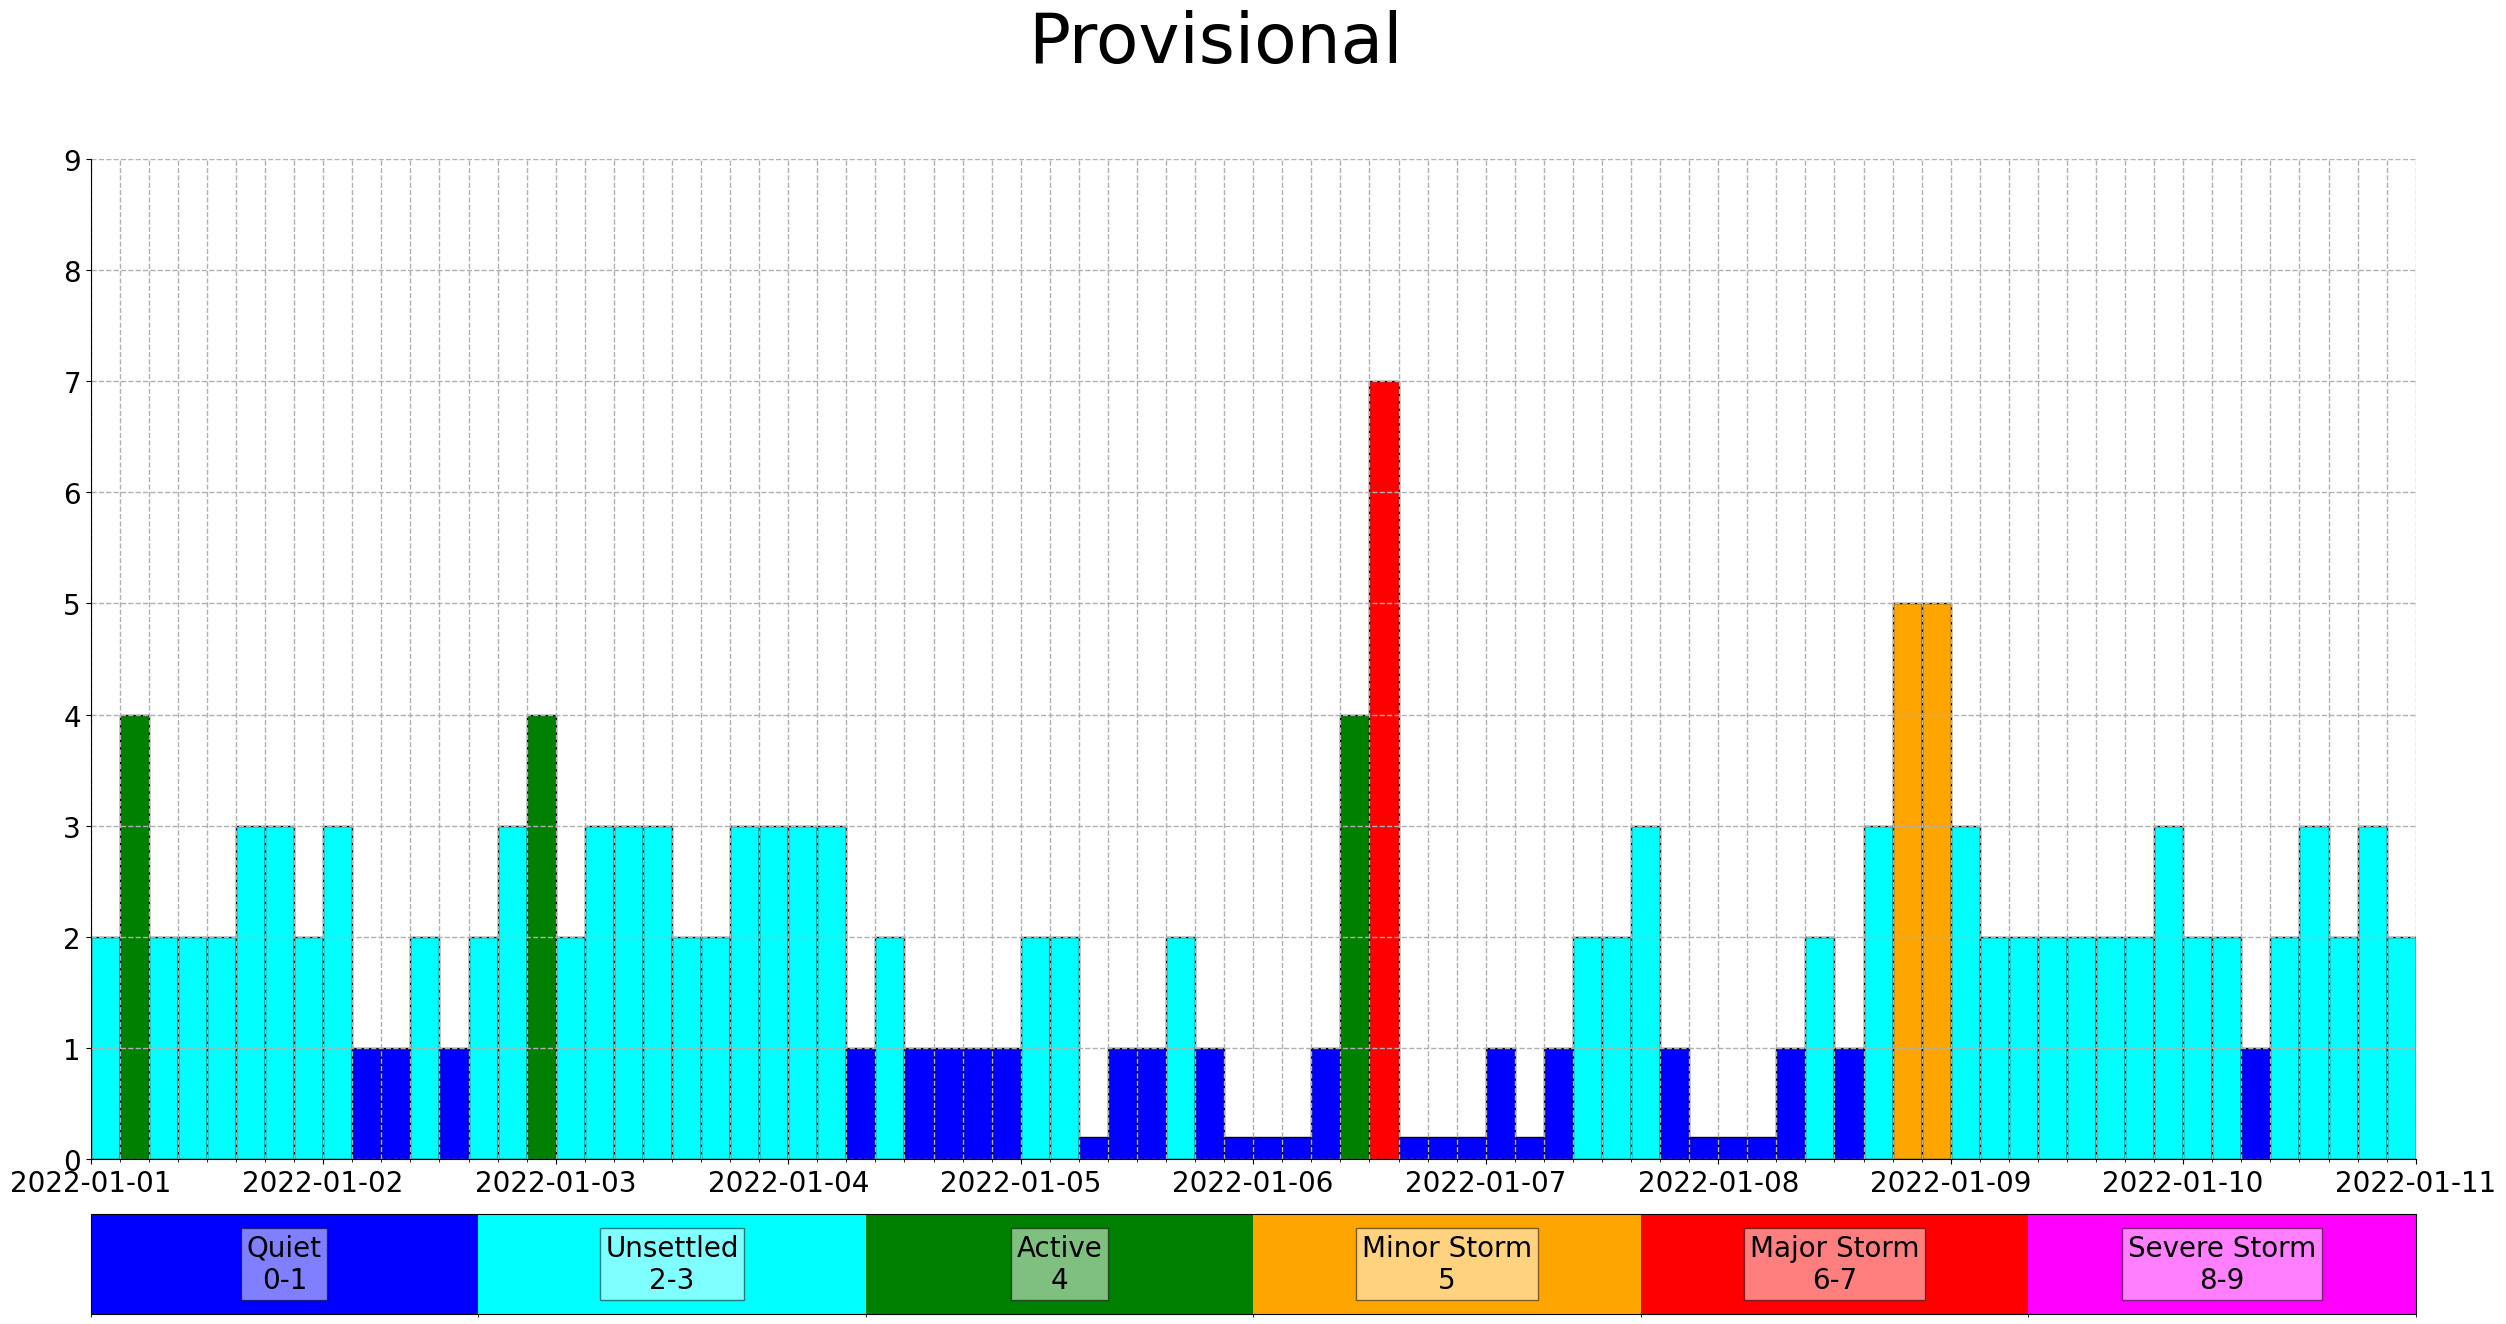

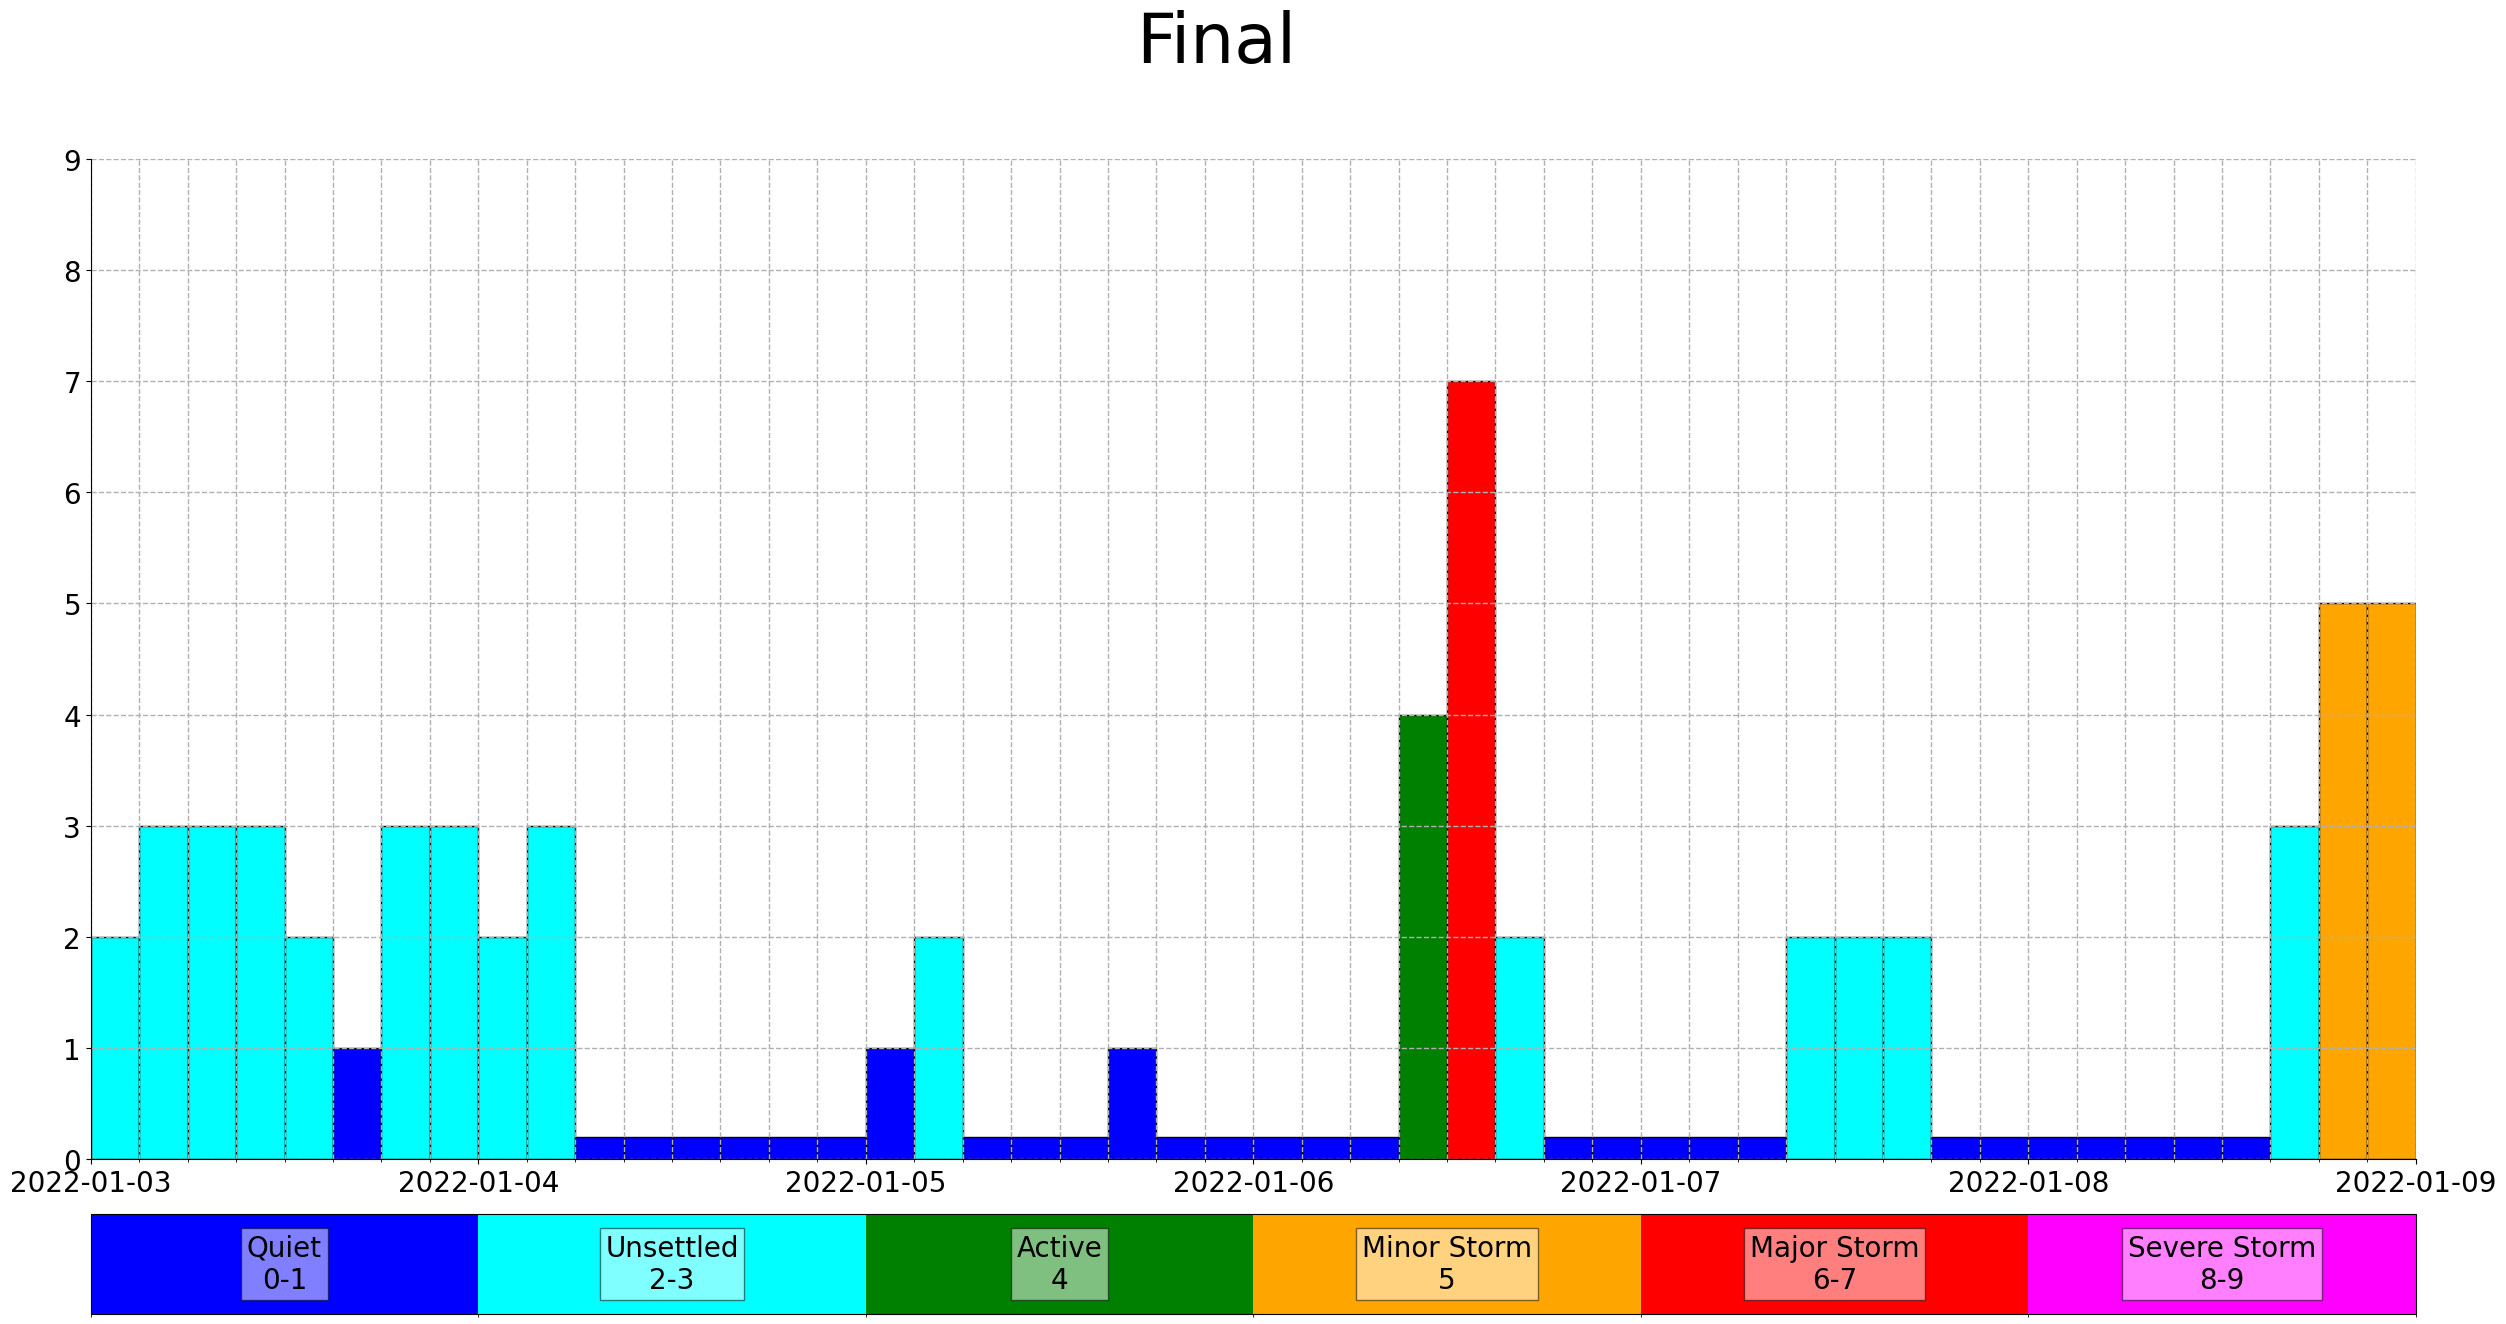

In [21]:
from magie import plot_k
fig, ax, cax= plot_k(pd.read_hdf('../Data/Dunsink.hdf5',
                                key='provisional_K'))
fig.suptitle('Provisional', size=50)
fig, ax, cax= plot_k(pd.read_hdf('../Data/Dunsink.hdf5',
                                key='final_K'))
fig.suptitle('Final', size=50)